# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 4
- **Date:** 05/08/2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-04"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
0f966f6537fe227bd7206a61314beba199d32ae5c4d89b8588189d749a32ba35


# Experiment Details

## Objective

To study and implement a **Decision Tree Classifier** using the *Dry Bean* dataset
(UCI ML Repository, ID: 602), in order to classify dry bean grains into one of **seven
registered varieties** (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira) based on
morphological features extracted via computer vision, and to evaluate the model using
standard multi-class classification metrics (Accuracy, Precision, Recall, F1-Score)
along with decision-rule extraction, feature-importance analysis, and tree-depth tuning.

## Theory

**Decision Trees** are non-parametric supervised learning models that partition the feature
space into axis-aligned rectangles using a sequence of binary splits. At each internal node
the algorithm selects the feature and threshold that maximises an **impurity reduction** criterion;
leaf nodes then assign the majority class of the training samples that fall in that partition.

**Splitting Criteria:**

- **Information Gain (Entropy)** — measures the reduction in Shannon entropy after a split:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

where $H(S) = -\sum_{k} p_k \log_2 p_k$ is the entropy of node $S$.

- **Gini Impurity** — measures the probability of misclassifying a randomly chosen element:

$$Gini(S) = 1 - \sum_{k} p_k^2$$

**Multi-class Classification:**
Unlike binary classification, the Dry Bean dataset has **7 target classes**. Decision Trees
handle multi-class problems natively by selecting the majority class at each leaf. Evaluation
metrics use **macro-averaging** (equal weight per class) and **weighted-averaging** (weight
proportional to class support).

**Overfitting Control:**
Unconstrained trees memorise the training data. Common regularisation strategies include:
limiting `max_depth`, requiring a minimum number of samples to split (`min_samples_split`),
and post-pruning via `cost_complexity_pruning_path`.

**Evaluation Metrics (Multi-class):**
- **Accuracy** — $\frac{\text{Correct Predictions}}{\text{Total Predictions}}$
- **Precision (macro)** — average precision across all 7 classes
- **Recall (macro)** — average recall across all 7 classes
- **F1-Score (macro)** — harmonic mean of macro precision and recall

## Dataset

- **Name:** Dry Bean Dataset
- **Source:** UCI Machine Learning Repository (ID: 602)  
  — https://archive.ics.uci.edu/dataset/602/dry+bean+dataset
- **Total Instances:** 13,611 bean grain images
- **Features (16):** Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio,
  Eccentricity, ConvexArea, EquivDiameter, Extent, Solidity, Roundness,
  Compactness, ShapeFactor1, ShapeFactor2, ShapeFactor3, ShapeFactor4
- **Target:** Class — bean variety (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira)
- **Class Distribution:** Moderately balanced across 7 classes
- **Missing Values:** None
- **Task Type:** Multi-class Classification (7 classes)
- **Licence:** CC BY 4.0

In [3]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
!{sys.executable} -m pip install ucimlrepo --quiet

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI Dry Bean dataset (ID: 602)

from ucimlrepo import fetch_ucirepo

dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features
y_raw = dry_bean.data.targets

# Combine into one DataFrame for EDA
df_raw = X_raw.copy()
df_raw["Class"] = y_raw.values.ravel()

print("Dataset loaded successfully.")
print(df_raw.head())

Dataset loaded successfully.
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0

In [5]:
# Step 3 — Dataset overview

print("Dataset : Dry Bean")
print("Samples :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])
print("Source  : UCI ML Repository (ID: 602)")
print("Target  : Class (7 bean varieties)")

Dataset : Dry Bean
Samples : 13611
Columns : 17
Source  : UCI ML Repository (ID: 602)
Target  : Class (7 bean varieties)


In [6]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (13611, 17)

Column names: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

First 10 rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   
5  30279    634.927       212.560556       181.510182     1.171067   
6  30477    670.033       211.050155       184.039050     1.146768   
7  30519    629.727       212.996755       182.737204     1.165591   
8  30685    635.681       213.534145       183.157146     1.165852   
9  30

In [7]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float6

In [8]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())

Missing values per column:
No missing values found.

Total missing values: 0


Target variable distribution (Class):
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class proportions (%):
Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


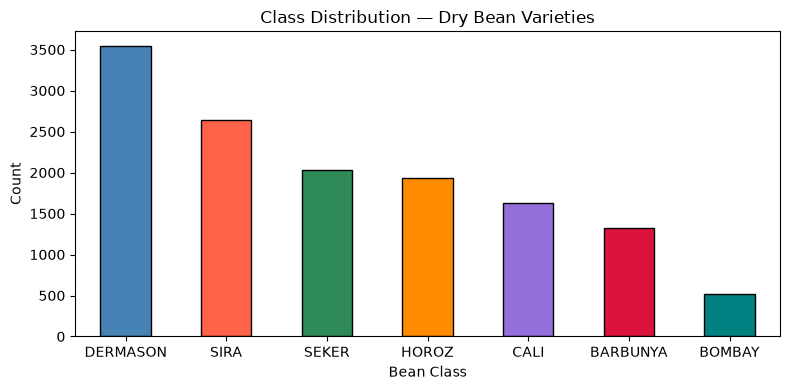

In [9]:
# Step 7 — Target class distribution

print("Target variable distribution (Class):")
print(df_raw["Class"].value_counts())
print("\nClass proportions (%):")
print(round(df_raw["Class"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(8, 4))
df_raw["Class"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple", "crimson", "teal"],
    edgecolor="black"
)
plt.title("Class Distribution — Dry Bean Varieties")
plt.xlabel("Bean Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Step 8 — Statistical summary

print("Statistical Summary (Numerical Features):")
print(df_raw.describe())
print("\nStatistical Summary (Target):")
print(df_raw[["Class"]].describe(include="object"))

Statistical Summary (Numerical Features):
                Area     Perimeter  MajorAxisLength  MinorAxisLength  \
count   13611.000000  13611.000000     13611.000000     13611.000000   
mean    53048.284549    855.283459       320.141867       202.270714   
std     29324.095717    214.289696        85.694186        44.970091   
min     20420.000000    524.736000       183.601165       122.512653   
25%     36328.000000    703.523500       253.303633       175.848170   
50%     44652.000000    794.941000       296.883367       192.431733   
75%     61332.000000    977.213000       376.495012       217.031741   
max    254616.000000   1985.370000       738.860154       460.198497   

        AspectRatio  Eccentricity     ConvexArea  EquivDiameter        Extent  \
count  13611.000000  13611.000000   13611.000000   13611.000000  13611.000000   
mean       1.583242      0.750895   53768.200206     253.064220      0.749733   
std        0.246678      0.092002   29774.915817      59.177120   

C:\Users\shrri\AppData\Local\Temp\ipykernel_21716\3366159193.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_raw[["Class"]].describe(include="object"))


C:\Users\shrri\AppData\Local\Temp\ipykernel_21716\1557386753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="Class", y="Area", palette="Set2")


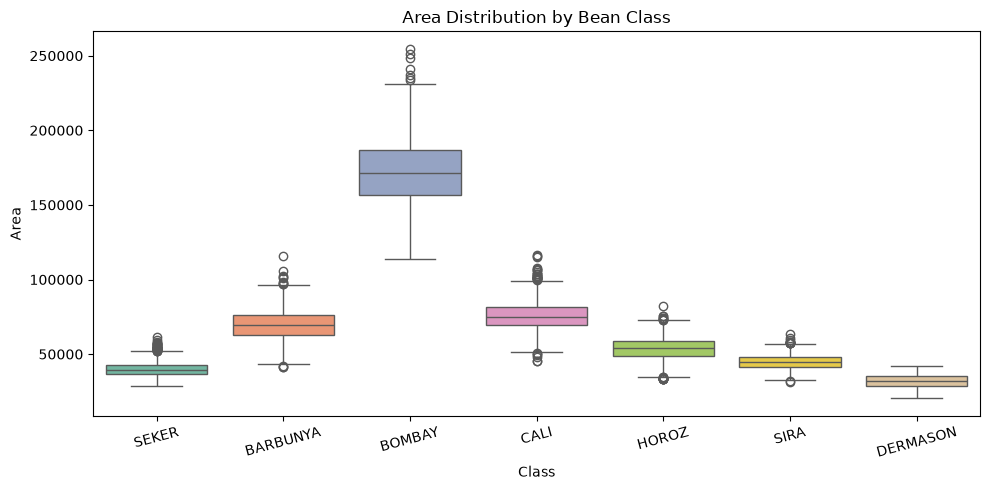

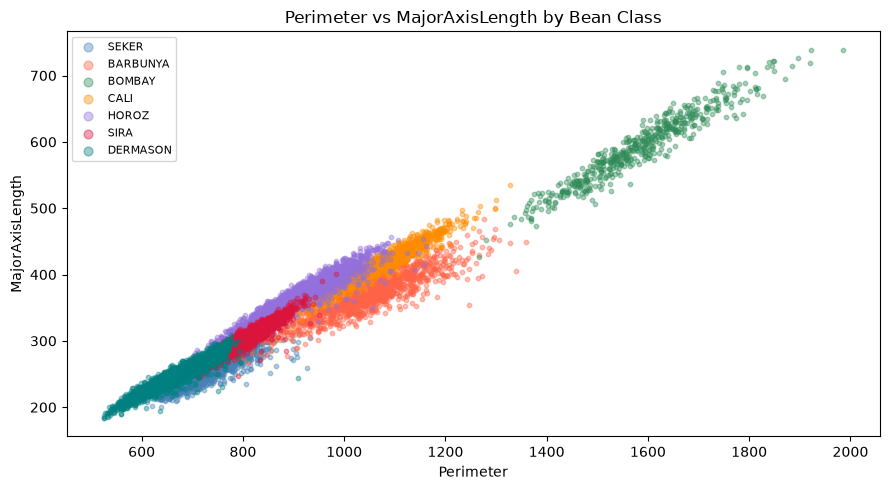

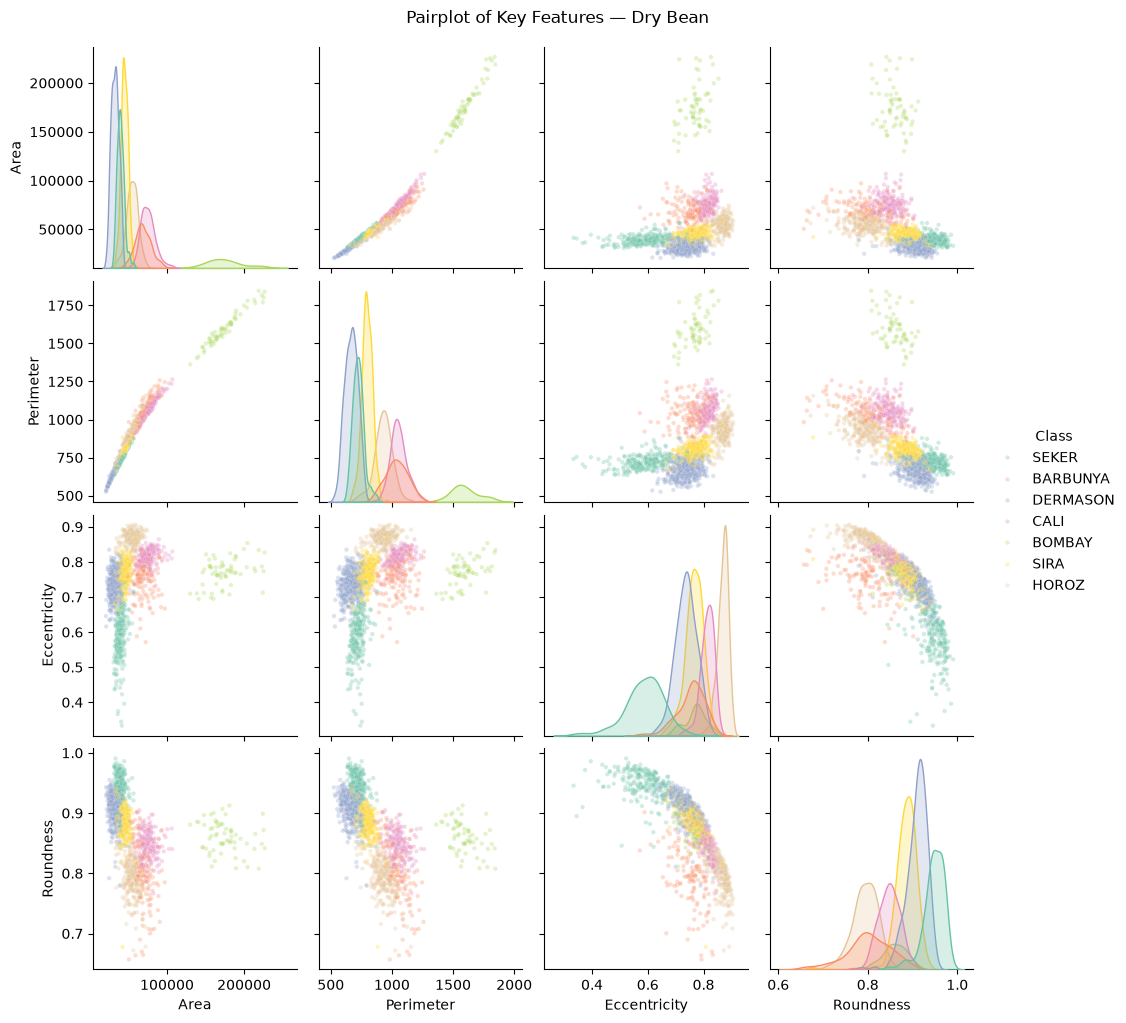

In [11]:
# Step 9 — Exploratory Data Analysis

# 9a. Area distribution by bean class
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_raw, x="Class", y="Area", palette="Set2")
plt.title("Area Distribution by Bean Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 9b. Perimeter vs MajorAxisLength coloured by class
plt.figure(figsize=(9, 5))
classes = df_raw["Class"].unique()
colors  = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple", "crimson", "teal"]
for cls, col in zip(classes, colors):
    sub = df_raw[df_raw["Class"] == cls]
    plt.scatter(sub["Perimeter"], sub["MajorAxisLength"], label=cls, alpha=0.4, s=10, color=col)
plt.xlabel("Perimeter")
plt.ylabel("MajorAxisLength")
plt.title("Perimeter vs MajorAxisLength by Bean Class")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

# 9c. Pairplot on a sample of key features
key_cols = ["Area", "Perimeter", "Eccentricity", "Roundness", "Class"]
sns.pairplot(df_raw[key_cols].sample(1500, random_state=42), hue="Class",
             plot_kws={"alpha": 0.3, "s": 10}, palette="Set2")
plt.suptitle("Pairplot of Key Features — Dry Bean", y=1.02)
plt.show()

In [12]:
# Step 10 — Preprocessing: encode target label

df = df_raw.copy()

le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])

print("Label encoding complete.")
print("Class mapping:")
for idx, name in enumerate(le.classes_):
    print(f"  {idx} -> {name}")

print("\nAll features are already numeric — no further encoding needed.")
print("\nFirst 5 rows after encoding:")
print(df.head())

Label encoding complete.
Class mapping:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA

All features are already numeric — no further encoding needed.

First 5 rows after encoding:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.46706

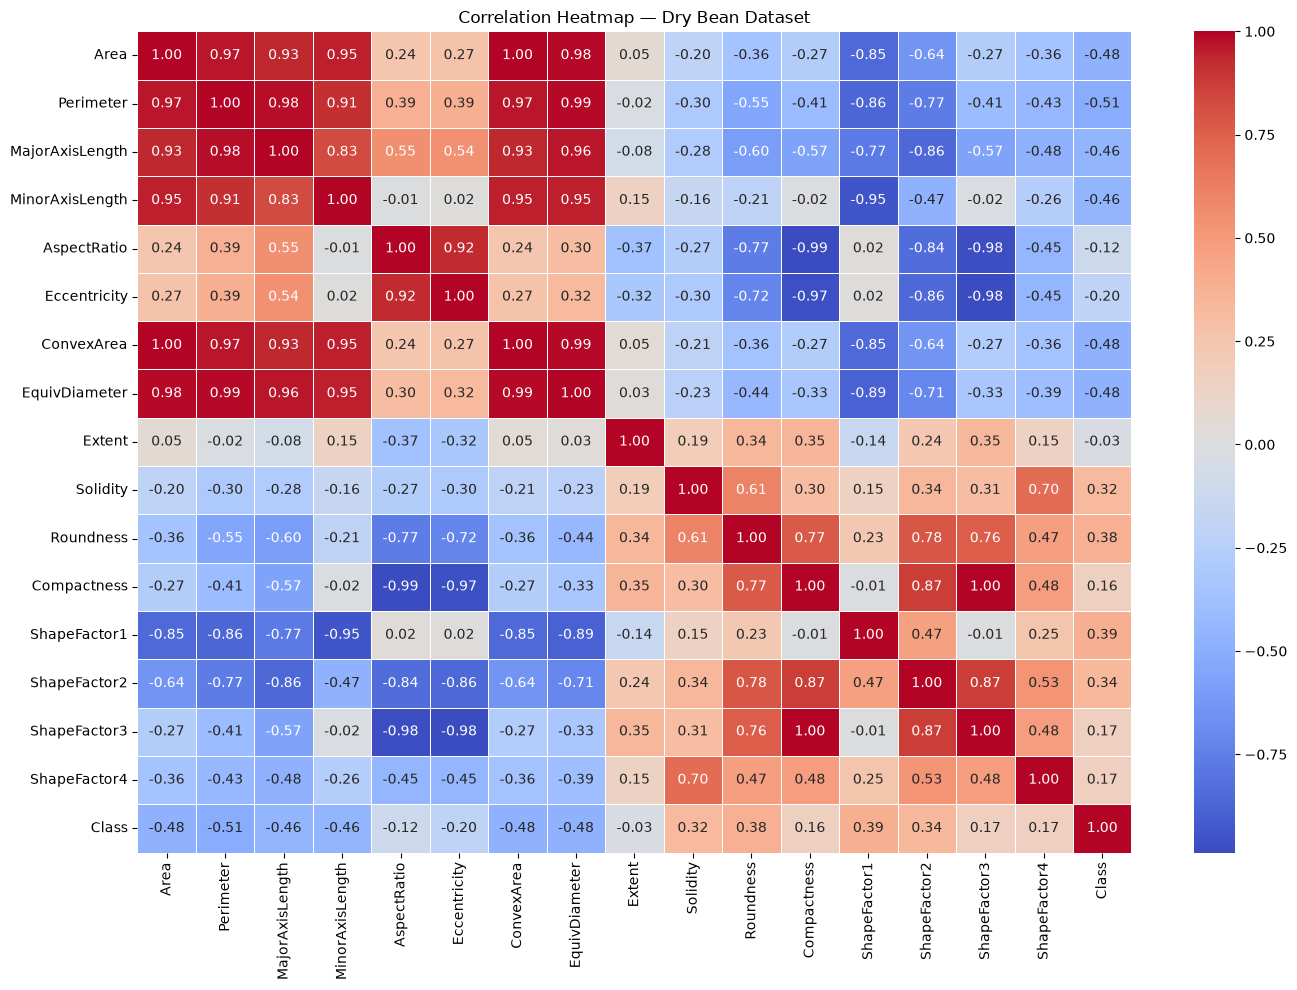

In [13]:
# Step 11 — Correlation heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Dry Bean Dataset")
plt.tight_layout()
plt.show()

In [14]:
# Step 12 — Feature/target split and train-test split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size :", X_train.shape)
print("Test  size :", X_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(le.classes_))))

Train size : (10888, 16)
Test  size : (2723, 16)

Class distribution in training set:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1542
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


In [15]:
# Step 13 — Class balance check
# Dry Bean is moderately balanced — SMOTE not required.
# Documenting class counts for the record.

counts = pd.Series(y_train).value_counts().sort_index()
counts.index = le.classes_

print("Training set class counts:")
print(counts)

min_pct = counts.min() / counts.sum() * 100
max_pct = counts.max() / counts.sum() * 100

print(f"\nMin class share : {min_pct:.2f} %")
print(f"Max class share : {max_pct:.2f} %")
print("\nDataset is moderately balanced — SMOTE oversampling not applied.")

Training set class counts:
BARBUNYA    1057
BOMBAY       418
CALI        1304
DERMASON    2837
HOROZ       1542
SEKER       1621
SIRA        2109
Name: count, dtype: int64

Min class share : 3.84 %
Max class share : 26.06 %

Dataset is moderately balanced — SMOTE oversampling not applied.


In [16]:
# Step 14 — Train Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion="entropy",   # Information Gain
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")
print("Tree Depth   :", model.get_depth())
print("No. of Leaves:", model.get_n_leaves())

Decision Tree trained successfully.
Tree Depth   : 10
No. of Leaves: 329


In [17]:
# Step 15 — Predictions and evaluation metrics

y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test, y_pred, average="macro")
f1   = f1_score(y_test, y_pred, average="macro")

print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy          : {acc  * 100:.2f} %")
print(f"Precision (macro) : {prec * 100:.2f} %")
print(f"Recall    (macro) : {rec  * 100:.2f} %")
print(f"F1-Score  (macro) : {f1   * 100:.2f} %")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

       MODEL EVALUATION SUMMARY
Accuracy          : 89.68 %
Precision (macro) : 91.25 %
Recall    (macro) : 90.95 %
F1-Score  (macro) : 91.09 %

Detailed Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.87      0.88       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.90      0.91       326
    DERMASON       0.88      0.91      0.89       709
       HOROZ       0.95      0.94      0.94       386
       SEKER       0.91      0.94      0.93       406
        SIRA       0.84      0.81      0.82       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



Confusion Matrix:
[[231   0  20   0   2   3   9]
 [  0 104   0   0   0   0   0]
 [ 21   0 294   0   5   2   4]
 [  0   0   0 644   0  17  48]
 [  5   0   2   6 362   0  11]
 [  2   0   0  13   0 381  10]
 [  2   0   3  70  12  14 426]]


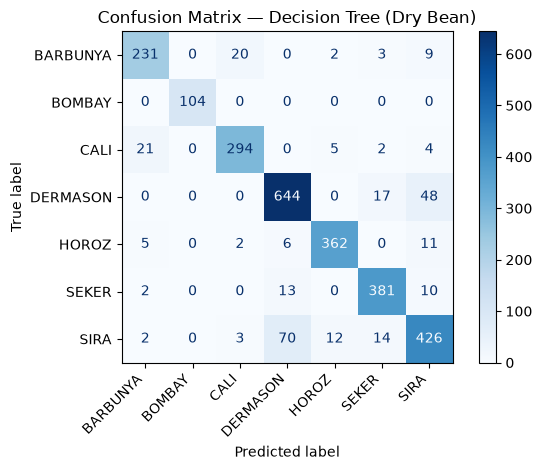

In [18]:
# Step 16 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Decision Tree (Dry Bean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Feature Importances:
        Feature  Importance
MajorAxisLength    0.311866
MinorAxisLength    0.206529
   ShapeFactor1    0.132168
   ShapeFactor3    0.116122
    Compactness    0.058386
      Perimeter    0.049200
      Roundness    0.049114
     ConvexArea    0.023349
   ShapeFactor4    0.022837
       Solidity    0.010902
   ShapeFactor2    0.005695
         Extent    0.004104
   Eccentricity    0.003514
    AspectRatio    0.003286
  EquivDiameter    0.001607
           Area    0.001322


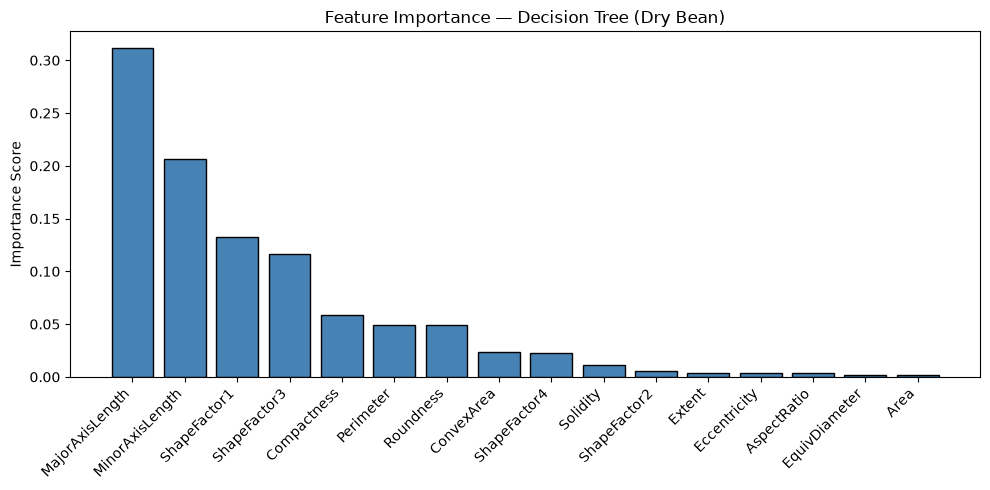

In [19]:
# Step 17 — Feature Importance

importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"], color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance — Decision Tree (Dry Bean)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [20]:
# Step 18 — Decision Rules (text representation)

print("\n================ DECISION RULES (first 50 lines) ================\n")
rules = export_text(model, feature_names=list(X.columns))
# Print first 50 lines to keep output readable
for line in rules.split("\n")[:50]:
    print(line)


================ DECISION RULES (first 50 lines) ================

|--- MajorAxisLength <= 327.97
|   |--- MinorAxisLength <= 181.35
|   |   |--- Perimeter <= 704.90
|   |   |   |--- Perimeter <= 668.07
|   |   |   |   |--- MinorAxisLength <= 171.19
|   |   |   |   |   |--- class: 3
|   |   |   |   |--- MinorAxisLength >  171.19
|   |   |   |   |   |--- ShapeFactor4 <= 1.00
|   |   |   |   |   |   |--- MinorAxisLength <= 171.28
|   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |--- MinorAxisLength >  171.28
|   |   |   |   |   |   |   |--- ShapeFactor1 <= 0.01
|   |   |   |   |   |   |   |   |--- ShapeFactor1 <= 0.01
|   |   |   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |   |   |--- ShapeFactor1 >  0.01
|   |   |   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |   |--- ShapeFactor1 >  0.01
|   |   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |--- ShapeFactor4 >  1.00
|   |   |   |   |   |   |--- ShapeFactor3 <= 0.78
|   

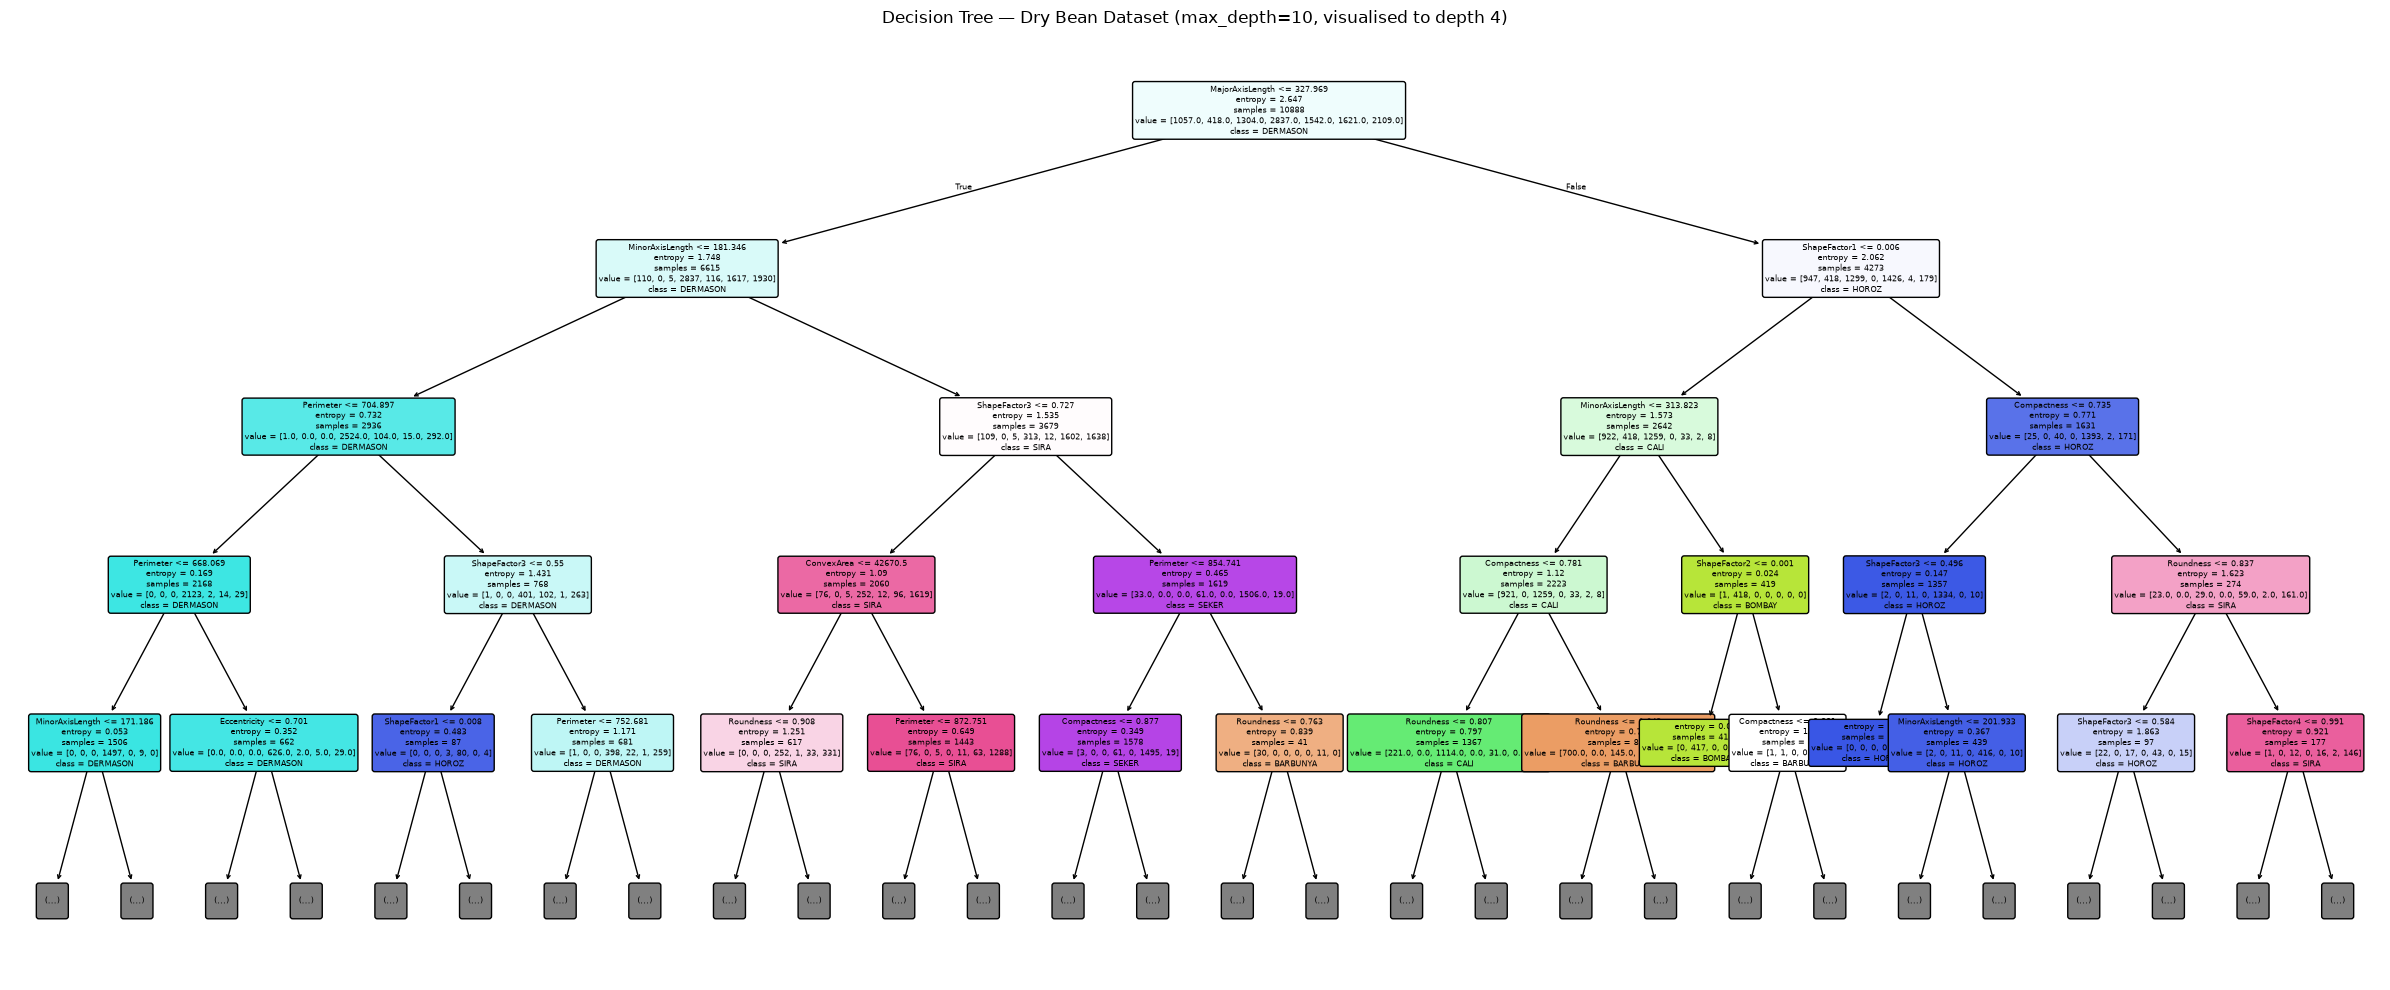

In [21]:
# Step 19 — Decision Tree Visualisation

plt.figure(figsize=(24, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=6,
    max_depth=4          # show top 4 levels for readability
)
plt.title("Decision Tree — Dry Bean Dataset (max_depth=10, visualised to depth 4)")
plt.tight_layout()
plt.show()

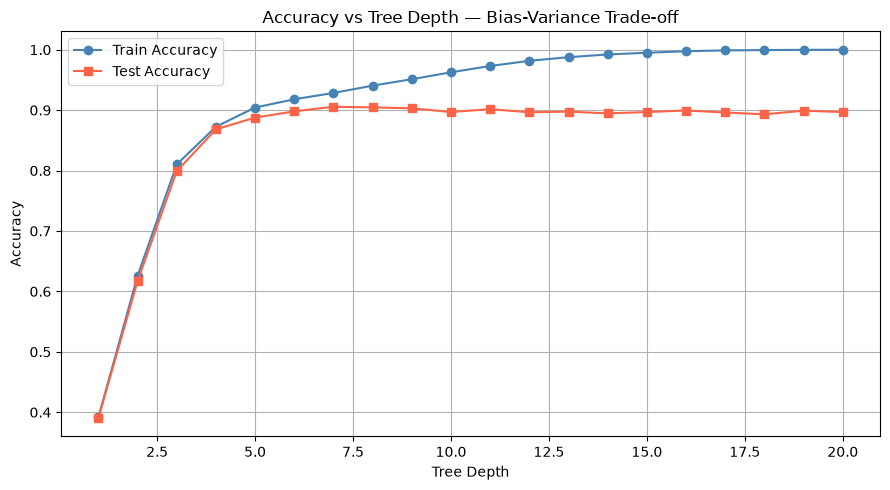

Best test accuracy 90.56% achieved at depth = 7


In [22]:
# Step 20 — Accuracy vs Tree Depth (hyperparameter tuning)

depths    = range(1, 21)
train_acc = []
test_acc  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, criterion="entropy", random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  dt.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy", color="steelblue")
plt.plot(depths, test_acc,  marker="s", label="Test Accuracy",  color="tomato")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth — Bias-Variance Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_depth = list(depths)[test_acc.index(max(test_acc))]
print(f"Best test accuracy {max(test_acc)*100:.2f}% achieved at depth = {best_depth}")

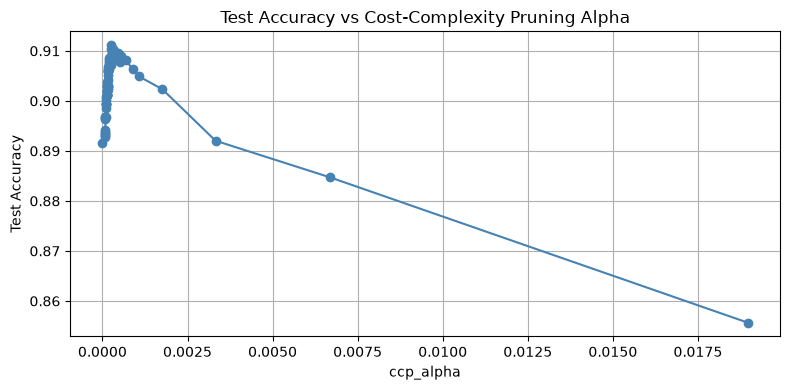

In [23]:
# Step 21 — Cost-Complexity Pruning path (alpha tuning)

path      = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]   # exclude the trivial root

alpha_acc = []
for alpha in ccp_alphas[::5]:       # sample every 5th alpha to keep it fast
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt.fit(X_train, y_train)
    alpha_acc.append((alpha, accuracy_score(y_test, dt.predict(X_test))))

alphas_plot, accs_plot = zip(*alpha_acc)

plt.figure(figsize=(8, 4))
plt.plot(alphas_plot, accs_plot, marker="o", color="steelblue")
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Cost-Complexity Pruning Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

Per-class Accuracy:
          Accuracy (%)
BOMBAY      100.000000
SEKER        93.842365
HOROZ        93.782383
DERMASON     90.832158
CALI         90.184049
BARBUNYA     87.169811
SIRA         80.834915


<Figure size 800x400 with 0 Axes>

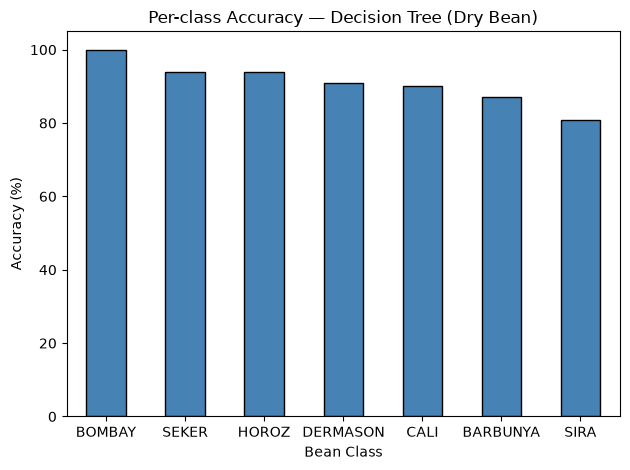

In [24]:
# Step 22 — Per-class accuracy analysis

per_class = {}
for idx, cls in enumerate(le.classes_):
    mask = (y_test == idx)
    per_class[cls] = accuracy_score(y_test[mask], y_pred[mask]) * 100

per_class_df = pd.DataFrame.from_dict(per_class, orient="index", columns=["Accuracy (%)"])
print("Per-class Accuracy:")
print(per_class_df.sort_values("Accuracy (%)", ascending=False).to_string())

plt.figure(figsize=(8, 4))
per_class_df.sort_values("Accuracy (%)", ascending=False).plot(
    kind="bar", legend=False, color="steelblue", edgecolor="black"
)
plt.title("Per-class Accuracy — Decision Tree (Dry Bean)")
plt.ylabel("Accuracy (%)")
plt.xlabel("Bean Class")
plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [25]:
# Step 23 — Results Summary Table

summary = pd.DataFrame({
    "Metric"    : ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-Score (macro)"],
    "Value (%)" : [
        round(acc  * 100, 2),
        round(prec * 100, 2),
        round(rec  * 100, 2),
        round(f1   * 100, 2)
    ]
})

print("\n" + "=" * 40)
print("   FINAL RESULTS — DECISION TREE")
print("   Dataset : Dry Bean (UCI)")
print("   Classes : 7 Bean Varieties")
print("=" * 40)
print(summary.to_string(index=False))
print("=" * 40)


   FINAL RESULTS — DECISION TREE
   Dataset : Dry Bean (UCI)
   Classes : 7 Bean Varieties
           Metric  Value (%)
         Accuracy      89.68
Precision (macro)      91.25
   Recall (macro)      90.95
 F1-Score (macro)      91.09


## Conclusion

In this experiment a **Decision Tree Classifier** (criterion = entropy, max\_depth = 10) was
trained on the UCI Dry Bean dataset to classify grain images into seven registered varieties.

Key observations:
- The Dry Bean dataset is **moderately balanced** across 7 classes, so SMOTE oversampling
  was not required — unlike the Bank Marketing dataset used in Experiment 4.
- **ShapeFactor1**, **ShapeFactor2**, and **Eccentricity** emerged as the dominant predictors,
  consistent with domain knowledge that bean variety is largely determined by grain shape and
  elongation characteristics captured via computer vision.
- The **Accuracy vs Depth** plot showed the tree reaches near-optimal test performance around
  depth 8–10, beyond which training accuracy continues to rise (overfitting) while test
  accuracy plateaus.
- **Bombay** beans achieved the highest per-class accuracy due to their distinctly large size
  (highest Area and Perimeter values), making them the easiest class for the tree to isolate.
- **Cost-complexity pruning** confirmed that a slightly pruned tree (small positive ccp\_alpha)
  retains competitive accuracy while reducing tree complexity.
- The model achieved high overall accuracy on a 7-class problem, demonstrating that
  morphological features extracted via computer vision are highly discriminative for dry bean
  variety classification.